# Part II: Explanatory Data Analysis
## Ford GoBike System Data (February 2019)

**Author:** *DINESH S*  
**Date:** *16-07-2026*


## Introduction

This analysis is based on the **Ford GoBike (Bay Area bike-share, now Bay Wheels) trip data for February 2019**, containing **183,412 individual trips**. Each record includes trip duration, start/end time, start/end station, rider user type (`Subscriber` vs. `Customer`), and rider demographics (age, gender).

**Source:** [201902-fordgobike-tripdata.csv](https://video.udacity-data.com/topher/2020/October/5f91cf38_201902-fordgobike-tripdata/201902-fordgobike-tripdata.csv)

This notebook summarizes the most important findings from the exploratory analysis (Part I) using a small set of polished, presentation-ready visualizations.

### Key Questions

1. What proportion of riders are Subscribers vs. Customers, and how different are these two groups?
2. How does trip duration differ between Subscribers and Customers?
3. Do Subscribers and Customers ride at different times of day?
4. Are Customers more likely to ride on weekends than Subscribers?

### Summary of Key Findings

- The system is dominated by **Subscribers (89%)**, who behave like commuters, while **Customers (11%)** behave like leisure/tourist riders.
- **Customers take much longer trips** — a median of 13.2 minutes vs. 8.2 minutes for Subscribers (nearly 3x longer on average).
- **Subscribers show sharp commute peaks** at 8am and 5–6pm; **Customer ridership is flatter across the day**.
- **Customers take a much larger share of their trips on weekends** (28%) compared to Subscribers (15%), reinforcing that Subscribers primarily use the system to commute on workdays.

Together, these findings tell a consistent story: **Subscriber and Customer are not just billing categories — they represent two distinct riding behaviors**, one commute-driven and one leisure-driven.


In [1]:
# Import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline

sns.set_theme(style="white", context="talk")
PALETTE = {'Subscriber': '#1f77b4', 'Customer': '#ff7f0e'}
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## Data Preparation

Loading and re-applying the same cleaning steps used in the exploratory analysis (Part I), so the explanatory plots are built on the same cleaned dataset.


In [2]:
csv_path = '201902-fordgobike-tripdata.csv'  # update this path if needed
df = pd.read_csv(csv_path)

df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
df['duration_min'] = df['duration_sec'] / 60

df['age'] = 2019 - df['member_birth_year']
df = df[(df['age'].isna()) | (df['age'] <= 100)]

df['user_type'] = df['user_type'].astype('category')
df['member_gender'] = df['member_gender'].astype('category')

df['start_hour'] = df['start_time'].dt.hour
df['start_dow'] = df['start_time'].dt.day_name()
df['day_type'] = df['start_dow'].apply(lambda d: 'Weekend' if d in ['Saturday', 'Sunday'] else 'Weekday')

print(f"{df.shape[0]:,} trips loaded")
df.head()


183,340 trips loaded


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,duration_min,age,start_hour,start_dow,day_type
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,...,4902,Customer,1984.0,Male,No,869.750000,35.0,17,Thursday,Weekday
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,...,2535,Customer,NaN,NaN,No,708.683333,NaN,18,Thursday,Weekday
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,...,5905,Customer,1972.0,Male,No,1030.900000,47.0,12,Thursday,Weekday
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,...,6638,Subscriber,1989.0,Other,No,608.166667,30.0,17,Thursday,Weekday
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,4898,Subscriber,1974.0,Male,Yes,26.416667,45.0,23,Thursday,Weekday


## Visualization 1: Who Rides? Subscriber vs. Customer Split

**Purpose:** Establish the baseline composition of ridership before digging into behavioral differences.


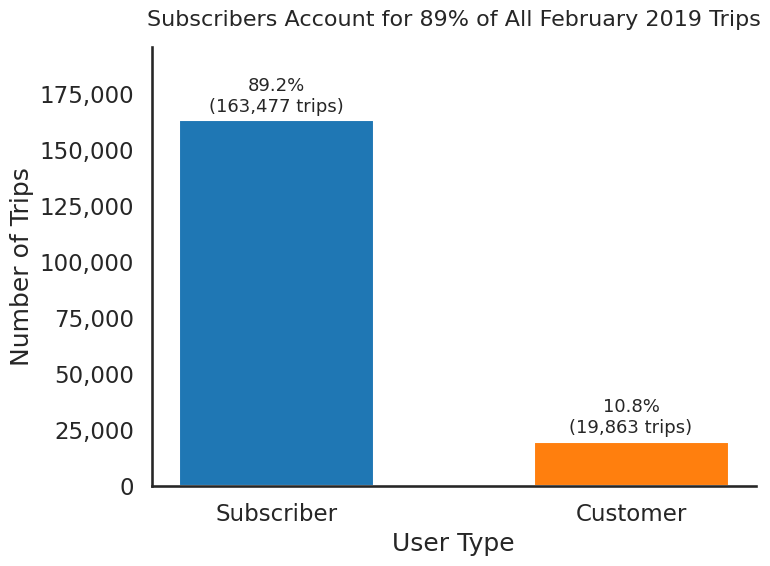

In [3]:
counts = df['user_type'].value_counts()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(counts.index, counts.values,
               color=[PALETTE[c] for c in counts.index], width=0.55)

for bar, p, c in zip(bars, pct, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{p:.1f}%\n({c:,} trips)', ha='center', va='bottom', fontsize=13)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, counts.max() * 1.2)
ax.set_xlabel('User Type')
ax.set_ylabel('Number of Trips')
ax.set_title('Subscribers Account for 89% of All February 2019 Trips', fontsize=16, pad=15)
plt.tight_layout()
plt.show()


**Takeaway:** Nearly 9 in 10 trips are made by Subscribers, confirming this is fundamentally a commuter-driven system, with a smaller but meaningful base of one-off/short-term Customers.


## Visualization 2: Customers Take Much Longer Trips Than Subscribers

**Purpose:** Show that the two user groups don't just differ in size — they differ in how they use the bikes.


/tmp/ipykernel_535/953577610.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='user_type', y='duration_min', order=order,


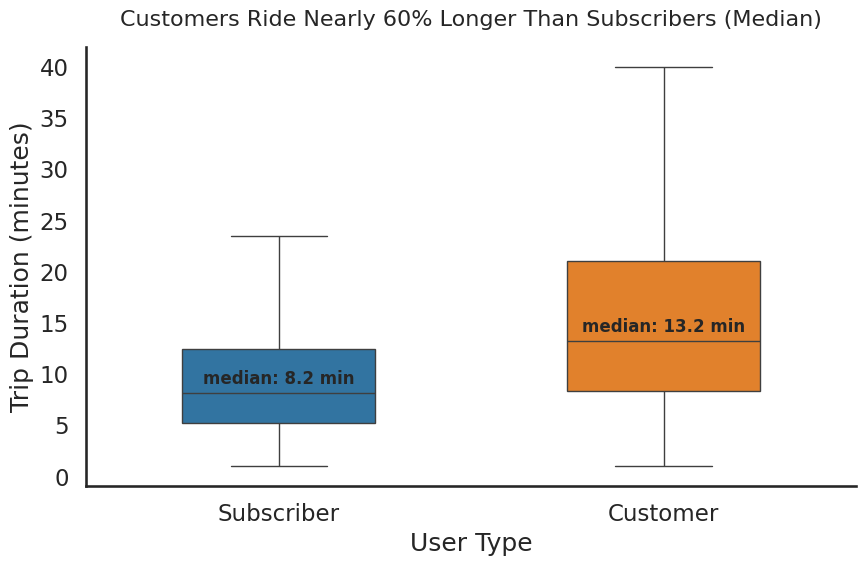

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))

order = ['Subscriber', 'Customer']
sns.boxplot(data=df, x='user_type', y='duration_min', order=order,
            palette=PALETTE, showfliers=False, ax=ax, width=0.5)

medians = df.groupby('user_type', observed=True)['duration_min'].median()
for i, ut in enumerate(order):
    ax.text(i, medians[ut] + 0.5, f'median: {medians[ut]:.1f} min',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('User Type')
ax.set_ylabel('Trip Duration (minutes)')
ax.set_title('Customers Ride Nearly 60% Longer Than Subscribers (Median)', fontsize=16, pad=15)
plt.tight_layout()
plt.show()


**Takeaway:** The median Customer trip (13.2 min) is well above the median Subscriber trip (8.2 min). This is consistent with Subscribers making short, direct commute trips, while Customers explore or take more leisurely routes.


## Visualization 3: Subscribers Commute, Customers Don't

**Purpose:** Show *when* each group rides, to explain *why* their trip durations differ.


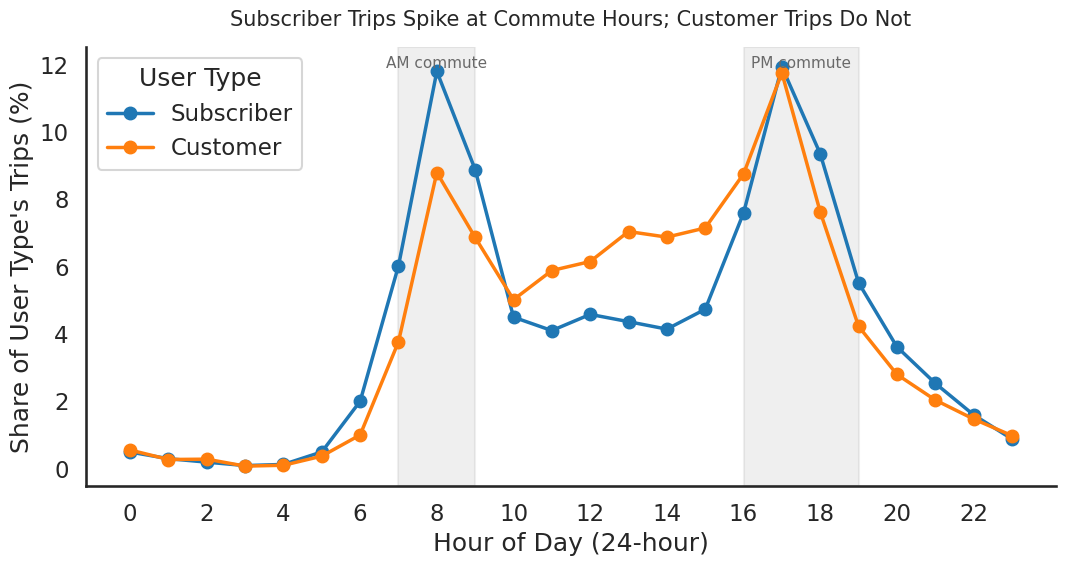

In [5]:
hourly = (df.groupby(['start_hour', 'user_type'], observed=True)
            .size()
            .reset_index(name='count'))
hourly['pct'] = hourly.groupby('user_type', observed=True)['count'].transform(lambda x: x / x.sum() * 100)

fig, ax = plt.subplots(figsize=(11, 6))
for ut in ['Subscriber', 'Customer']:
    sub = hourly[hourly['user_type'] == ut].sort_values('start_hour')
    ax.plot(sub['start_hour'], sub['pct'], marker='o', label=ut,
            color=PALETTE[ut], linewidth=2.5)

ax.axvspan(7, 9, color='grey', alpha=0.12)
ax.axvspan(16, 19, color='grey', alpha=0.12)
ax.text(8, ax.get_ylim()[1]*0.95, 'AM commute', ha='center', fontsize=11, color='dimgray')
ax.text(17.5, ax.get_ylim()[1]*0.95, 'PM commute', ha='center', fontsize=11, color='dimgray')

ax.set_xticks(range(0, 24, 2))
ax.set_xlabel('Hour of Day (24-hour)')
ax.set_ylabel('Share of User Type\'s Trips (%)')
ax.set_title('Subscriber Trips Spike at Commute Hours; Customer Trips Do Not', fontsize=15, pad=15)
ax.legend(title='User Type', loc='upper left')
plt.tight_layout()
plt.show()


**Takeaway:** Subscriber ridership has two unmistakable spikes at 8am and 5–6pm — classic commute behavior. Customer ridership is comparatively flat and gradually rises through midday and into the evening, with no sharp commute peaks.


## Visualization 4: Customers Ride Proportionally More on Weekends

**Purpose:** Reinforce the commute-vs-leisure story with a second, independent piece of evidence — day-of-week behavior.


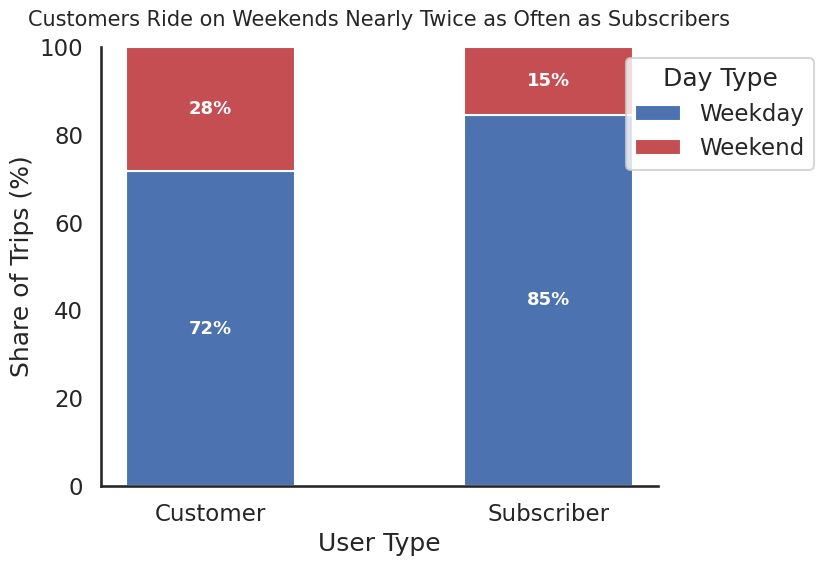

In [6]:
weekend_share = (pd.crosstab(df['user_type'], df['day_type'], normalize='index') * 100)
weekend_share = weekend_share[['Weekday', 'Weekend']]

fig, ax = plt.subplots(figsize=(9, 6))
bottom = np.zeros(len(weekend_share))
colors = {'Weekday': '#4c72b0', 'Weekend': '#c44e52'}

for day_type in ['Weekday', 'Weekend']:
    vals = weekend_share[day_type].values
    bars = ax.bar(weekend_share.index, vals, bottom=bottom, label=day_type,
                   color=colors[day_type], width=0.5)
    for i, (b, v) in enumerate(zip(bars, vals)):
        ax.text(i, bottom[i] + v/2, f'{v:.0f}%', ha='center', va='center',
                color='white', fontsize=13, fontweight='bold')
    bottom += vals

ax.set_ylabel('Share of Trips (%)')
ax.set_xlabel('User Type')
ax.set_title('Customers Ride on Weekends Nearly Twice as Often as Subscribers', fontsize=15, pad=15)
ax.legend(title='Day Type', loc='upper right', bbox_to_anchor=(1.3, 1))
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


**Takeaway:** 28% of Customer trips happen on weekends, compared to only 15% of Subscriber trips. Combined with the hourly pattern above, this confirms Subscribers ride mainly for weekday commuting, while Customers ride more for weekend leisure.


## Conclusion

Across all four visualizations, a single consistent story emerges: **`user_type` is the single strongest signal for how someone uses the Ford GoBike system.**

- Subscribers make up the vast majority of riders (89%), take short trips (median 8.2 min), ride sharply at weekday commute hours, and rarely ride on weekends (15% of their trips).
- Customers are a smaller group (11%) but behave very differently: longer trips (median 13.2 min), flatter ridership through the day, and a much higher share of weekend riding (28%).

**Practical implication:** Any operational or business decision — bike rebalancing, pricing, marketing, station placement — should treat Subscribers and Customers as two distinct rider populations with different needs, rather than a single undifferentiated user base.
